In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Palo Alto Networks (1).csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [44]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 31)


In [45]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [46]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Attrition
0    1233
1     237
Name: count, dtype: int64


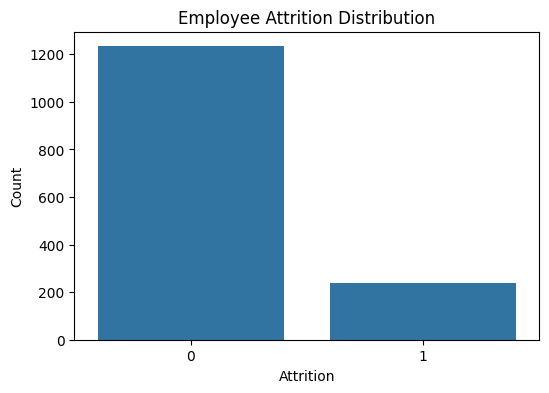

In [47]:
print(df["Attrition"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

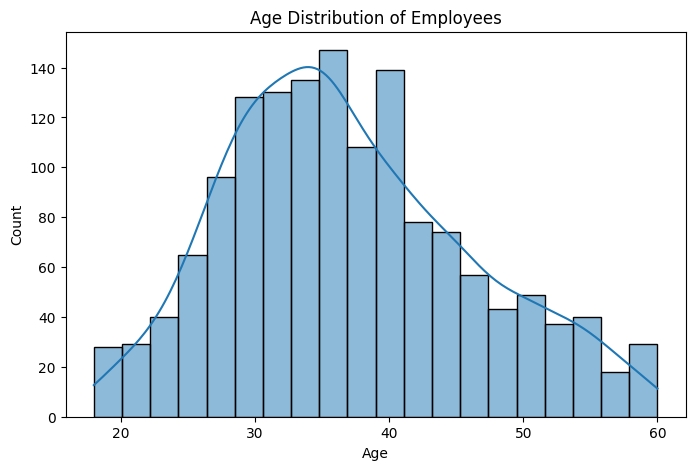

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

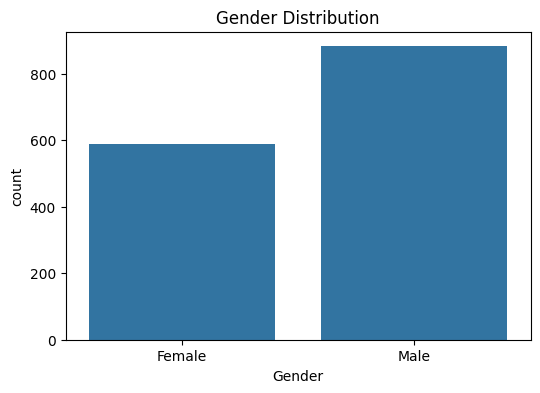

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

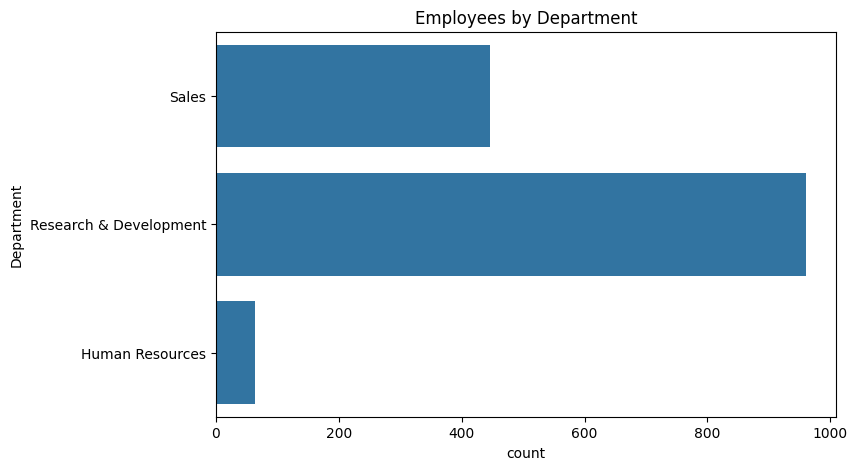

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(y="Department", data=df)

plt.title("Employees by Department")

plt.show()

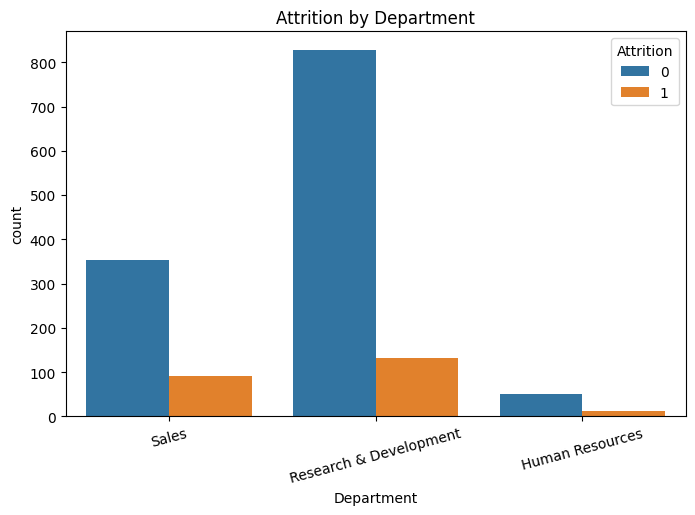

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(x="Department",
              hue="Attrition",
              data=df)

plt.title("Attrition by Department")

plt.xticks(rotation=15)

plt.show()

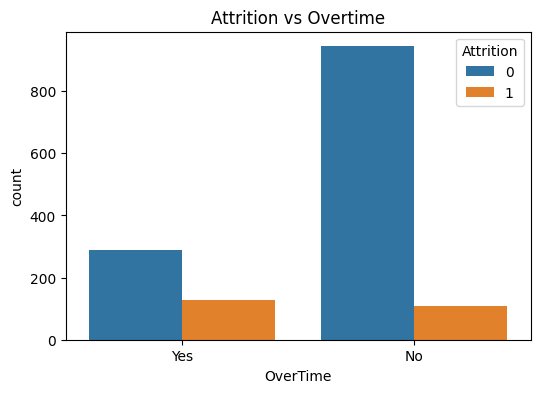

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(x="OverTime",
              hue="Attrition",
              data=df)

plt.title("Attrition vs Overtime")

plt.show()

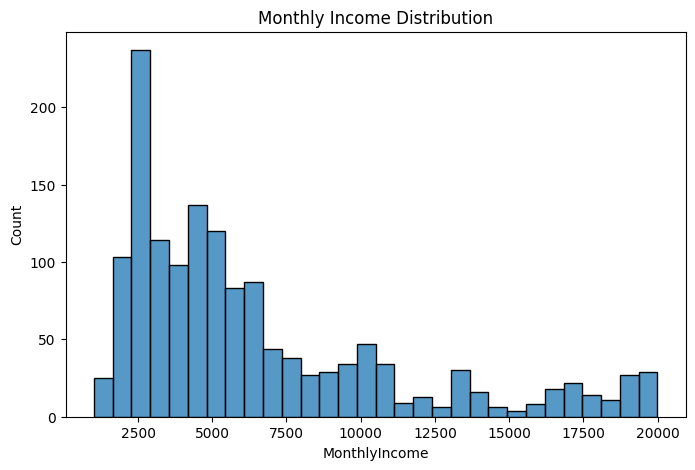

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=30)

plt.title("Monthly Income Distribution")

plt.show()

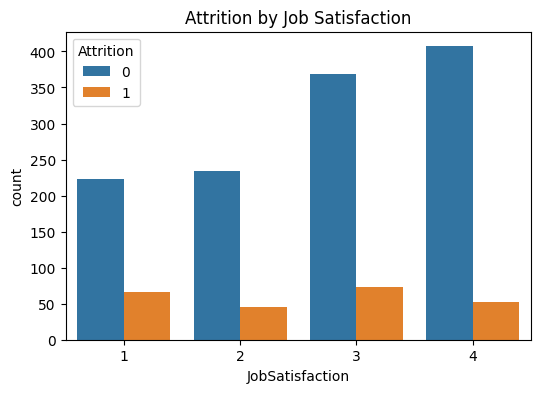

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(x="JobSatisfaction",
              hue="Attrition",
              data=df)

plt.title("Attrition by Job Satisfaction")

plt.show()

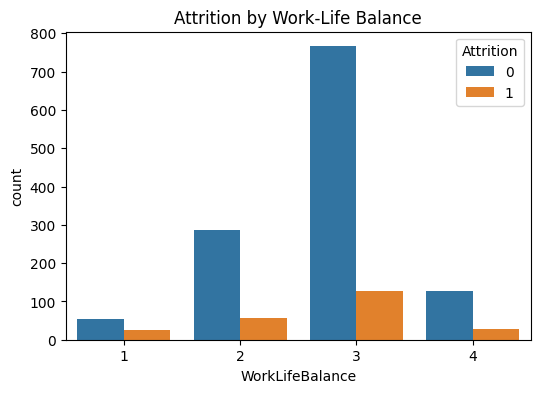

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(x="WorkLifeBalance",
              hue="Attrition",
              data=df)

plt.title("Attrition by Work-Life Balance")

plt.show()

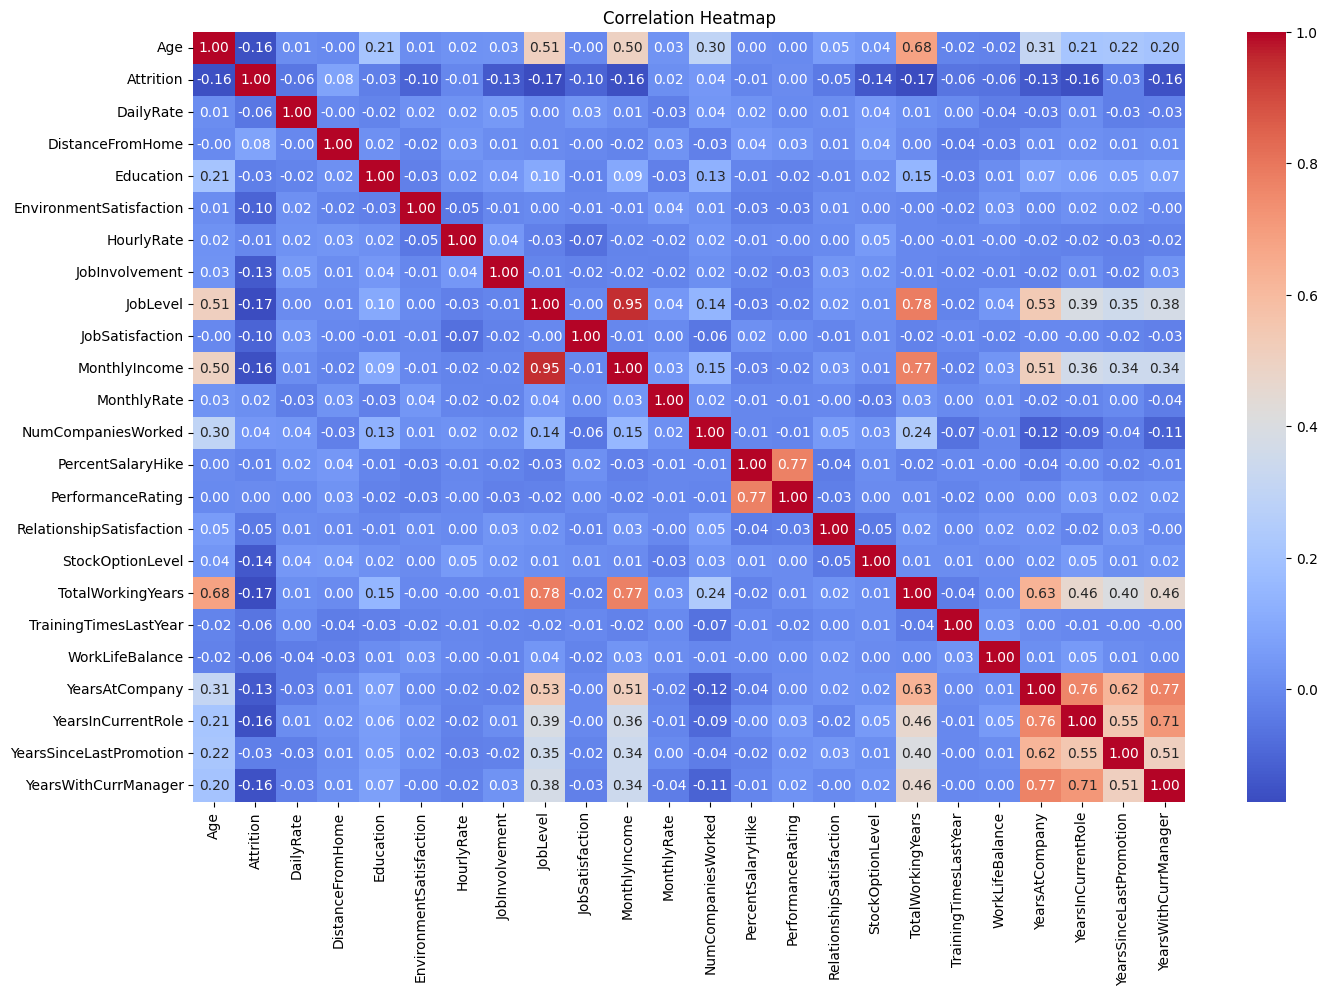

In [56]:
plt.figure(figsize=(16,10))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [57]:
print(df["Attrition"].value_counts())

print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


In [58]:
df["IncomeExperienceRatio"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)

df["PromotionDelay"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)

df["EngagementScore"] = (
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"] +
    df["JobInvolvement"]
) / 4

df["StressFlag"] = (
    (df["OverTime"] == "Yes") &
    (df["WorkLifeBalance"] <= 2)
).astype(int)

df[["IncomeExperienceRatio", "PromotionDelay", "EngagementScore", "StressFlag"]].head()

,IncomeExperienceRatio,PromotionDelay,EngagementScore,StressFlag
0,665.888889,0.000000,2.50,1
1,466.363636,0.090909,2.75,0
2,261.250000,0.000000,2.75,0
3,323.222222,0.333333,3.25,0
4,495.428571,0.666667,2.50,0


In [59]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [60]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'IncomeExperienceRatio', 'PromotionDelay', 'EngagementScore',
       'StressFlag'],
      dtype='object')


In [61]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.head())

   Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0   41       1102                 1          2                        2   
1   49        279                 8          1                        3   
2   37       1373                 2          2                        4   
3   33       1392                 3          4                        4   
4   27        591                 2          1                        1   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          94               3         2                4           5993  ...   
1          61               2         2                2           5130  ...   
2          92               2         1                3           2090  ...   
3          56               3         1                3           2909  ...   
4          40               3         1                2           3468  ...   

   JobRole_Laboratory Technician  JobRole_Manager  \
0              

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 48)
Testing Data: (294, 48)


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
!pip install imbalanced-learn

In [65]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train.value_counts())

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [67]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [68]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.7721088435374149
Precision: 0.36486486486486486
Recall   : 0.574468085106383
F1 Score : 0.4462809917355372
ROC AUC  : 0.7917133258678611


In [69]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [70]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.8367346938775511
Precision: 0.4782608695652174
Recall   : 0.23404255319148937
F1 Score : 0.3142857142857143
ROC AUC  : 0.7949435782582478


In [71]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [72]:
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC AUC  :", roc_auc_score(y_test, gb_prob))

Accuracy : 0.8639455782312925
Precision: 0.6296296296296297
Recall   : 0.3617021276595745
F1 Score : 0.4594594594594595
ROC AUC  : 0.791713325867861


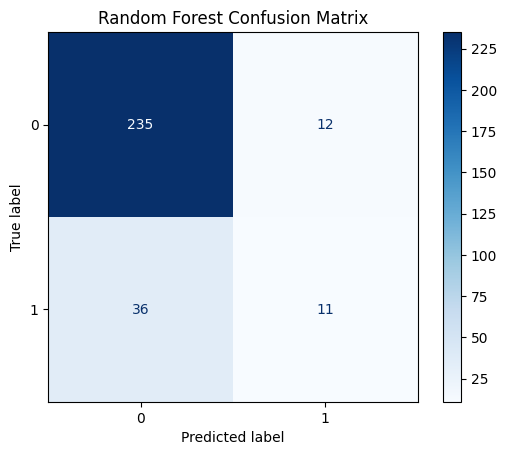

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [74]:
results = {
    "Model": ["Logistic Regression",
              "Random Forest",
              "Gradient Boosting"],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
}

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.772109,0.446281,0.791713
1,Random Forest,0.836735,0.314286,0.794944
2,Gradient Boosting,0.863946,0.459459,0.791713


In [75]:
risk_probability = rf.predict_proba(X_test)[:, 1]

In [76]:
def risk_category(prob):

    if prob < 0.30:
        return "Low Risk"

    elif prob < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [77]:
risk_df = pd.DataFrame({

    "Actual Attrition": y_test.values,
    "Predicted Probability": risk_probability

})

risk_df["Risk Category"] = risk_df["Predicted Probability"].apply(risk_category)

risk_df.head(10)

,Actual Attrition,Predicted Probability,Risk Category
0,0,0.610,High Risk
1,0,0.090,Low Risk
2,0,0.205,Low Risk
3,0,0.055,Low Risk
4,1,0.405,Medium Risk
5,0,0.270,Low Risk
6,0,0.130,Low Risk
7,0,0.165,Low Risk
8,0,0.040,Low Risk
9,0,0.610,High Risk


In [78]:
risk_df["Risk Category"].value_counts()

,count
Risk Category,
Low Risk,209
Medium Risk,74
High Risk,11


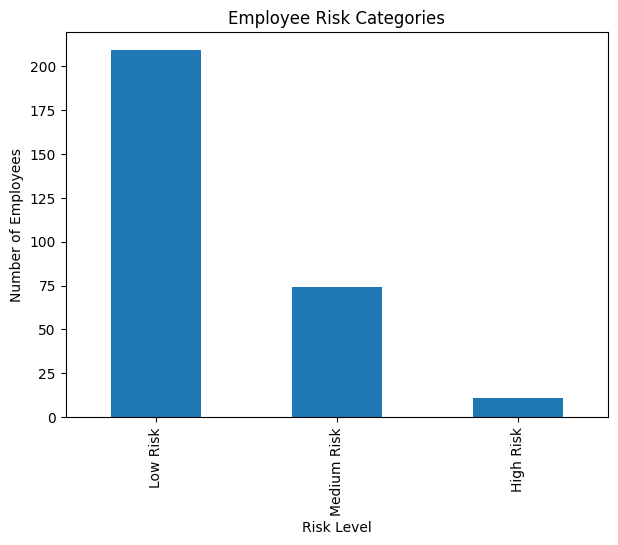

In [79]:
import matplotlib.pyplot as plt

risk_df["Risk Category"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Employee Risk Categories")
plt.xlabel("Risk Level")
plt.ylabel("Number of Employees")
plt.show()

In [80]:
high_risk = risk_df[
    risk_df["Risk Category"] == "High Risk"
]

high_risk.head(20)

,Actual Attrition,Predicted Probability,Risk Category
0,0,0.610,High Risk
9,0,0.610,High Risk
15,0,0.695,High Risk
35,1,0.635,High Risk
92,1,0.780,High Risk
106,0,0.715,High Risk
200,1,0.850,High Risk
214,1,0.715,High Risk
223,0,0.780,High Risk
241,0,0.680,High Risk


In [81]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
47,OverTime_Yes,0.073557
15,StockOptionLevel,0.056876
22,YearsWithCurrManager,0.046628
25,EngagementScore,0.041876
0,Age,0.040716
16,TotalWorkingYears,0.039870
9,MonthlyIncome,0.039426
19,YearsAtCompany,0.038571
8,JobSatisfaction,0.037409
7,JobLevel,0.035500


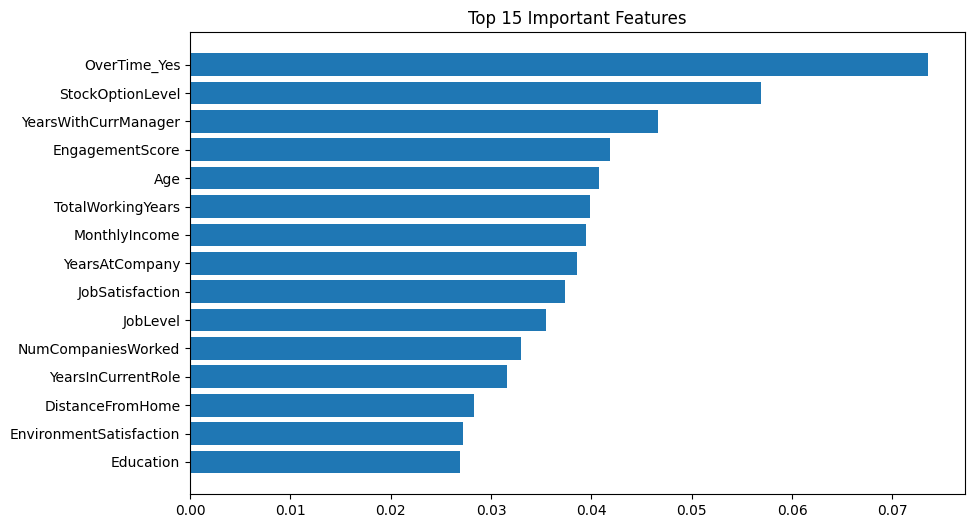

In [82]:
top = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()